In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# MLflow for experiment tracking
import mlflow
import mlflow.sklearn

import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print(f"MLflow version: {mlflow.__version__}")

MLflow version: 3.6.0


In [2]:
# Load the datasets
df_2011 = pd.read_csv('data/day_2011.csv')
df_2012 = pd.read_csv('data/day_2012.csv')

print("2011 dataset")
print(f"\nShape: {df_2011.shape}")
print(f"\nOverview:")
display(df_2011.head())
print(f"\nData types:")
print(df_2011.dtypes)
print(f"\nMissing values:")
print(df_2011.isnull().sum())
print(f"\nBasic statistics:")
display(df_2011.describe())

print("2012 dataset")
print(f"\nShape: {df_2012.shape}")
print(f"\nOverview:")
display(df_2012.head())
print(f"\nBasic statistics:")
display(df_2012.describe())

2011 dataset

Shape: (365, 12)

Overview:


,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,01/01/2011,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,02/01/2011,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,03/01/2011,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,04/01/2011,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,05/01/2011,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600



Data types:
dteday         object
season          int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

Missing values:
dteday        0
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Basic statistics:


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2.498630,6.526027,0.027397,3.008219,0.684932,1.421918,0.486665,0.466835,0.643665,0.191403,3405.761644
std,1.110946,3.452584,0.163462,2.006155,0.465181,0.571831,0.189596,0.168836,0.148744,0.076890,1378.753666
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,431.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.325000,0.321954,0.538333,0.135583,2132.000000
50%,3.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.479167,0.472846,0.647500,0.186900,3740.000000
75%,3.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.656667,0.612379,0.742083,0.235075,4586.000000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.849167,0.840896,0.972500,0.507463,6043.000000


2012 dataset

Shape: (366, 12)

Overview:


,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,01/01/2012,1,1,0,0,0,1,0.370000,0.375621,0.692500,0.192167,2294
1,02/01/2012,1,1,1,1,0,1,0.273043,0.252304,0.381304,0.329665,1951
2,03/01/2012,1,1,0,2,1,1,0.150000,0.126275,0.441250,0.365671,2236
3,04/01/2012,1,1,0,3,1,2,0.107500,0.119337,0.414583,0.184700,2368
4,05/01/2012,1,1,0,4,1,1,0.265833,0.278412,0.524167,0.129987,3272



Basic statistics:


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.494536,6.513661,0.030055,2.986339,0.683060,1.368852,0.504081,0.481852,0.612166,0.189572,5599.934426
std,1.112185,3.455958,0.170971,2.006108,0.465921,0.516057,0.176112,0.156756,0.134206,0.078194,1788.667868
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.107500,0.101658,0.254167,0.046650,22.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.347708,0.350685,0.508125,0.133721,4369.000000
50%,2.500000,7.000000,0.000000,3.000000,1.000000,1.000000,0.514167,0.497779,0.611875,0.174750,5927.000000
75%,3.000000,9.750000,0.000000,5.000000,1.000000,2.000000,0.653959,0.607646,0.711146,0.231196,7011.250000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.804913,0.925000,0.441563,8714.000000


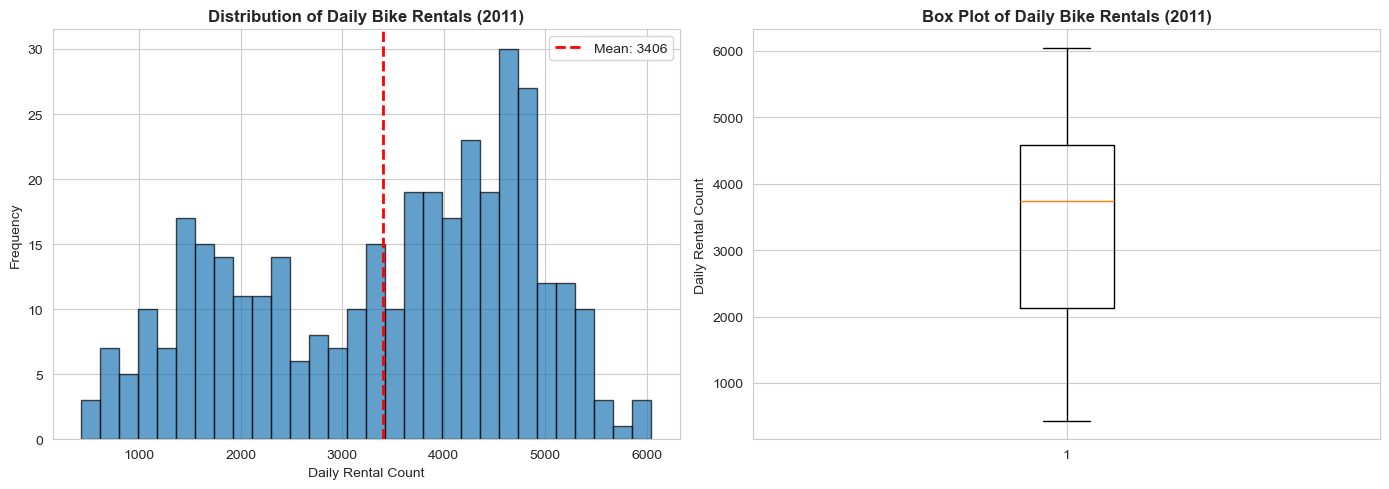

Target Variable Statistics:
Mean: 3405.76
Median: 3740.00
Std Dev: 1378.75
Min: 431.00
Max: 6043.00


In [3]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_2011['cnt'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Daily Bike Rentals (2011)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Rental Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_2011['cnt'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_2011["cnt"].mean():.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df_2011['cnt'], vert=True)
axes[1].set_title('Box Plot of Daily Bike Rentals (2011)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Rental Count')

plt.tight_layout()
plt.show()

print(f"Target Variable Statistics:")
print(f"Mean: {df_2011['cnt'].mean():.2f}")
print(f"Median: {df_2011['cnt'].median():.2f}")
print(f"Std Dev: {df_2011['cnt'].std():.2f}")
print(f"Min: {df_2011['cnt'].min():.2f}")
print(f"Max: {df_2011['cnt'].max():.2f}")

## Data Preprocessing

In [5]:
def preprocess_data(df, is_training=True):
    df_processed = df.copy()
    
    # Drop the date column (not numeric, already have month/weekday)
    if 'dteday' in df_processed.columns:
        df_processed = df_processed.drop('dteday', axis=1)
    
    # Separate features and target
    if is_training and 'cnt' in df_processed.columns:
        X = df_processed.drop('cnt', axis=1)
        y = df_processed['cnt']
        return X, y
    else:
        return df_processed

In [6]:
X_2011, y_2011 = preprocess_data(df_2011, is_training=True)

In [7]:
X_2012, y_2012 = preprocess_data(df_2012, is_training=True)

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_2011, y_2011, test_size=0.2, random_state=42)

# Task 1 - Model Development and Experiment Design

## MLFlow Setup

In [11]:
# Set up MLflow experiment
mlflow.set_experiment("Bike-Sharing-Demand-Prediction") 
mlflow.set_tracking_uri("http://localhost:5000")

print("MLflow experiment initialized: 'Bike-Sharing-Demand-Prediction'")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment ID: {mlflow.get_experiment_by_name('Bike-Sharing-Demand-Prediction').experiment_id}")

MLflow experiment initialized: 'Bike-Sharing-Demand-Prediction'
Tracking URI: http://localhost:5000
Experiment ID: 747516766537601300


In [12]:
# Model evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Train and evaluate a regression model, returning comprehensive metrics.
    
    Parameters:
    - model: sklearn model object
    - X_train, X_test, y_train, y_test: train-test split data
    - model_name: string name for the model
    
    Returns:
    - metrics: dictionary of evaluation metrics
    - trained_model: fitted model object
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics for both train and test sets
    metrics = {
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred)
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*60}")
    print(f"\nTraining Set:")
    print(f"  RMSE: {metrics['train_rmse']:.2f}")
    print(f"  MAE:  {metrics['train_mae']:.2f}")
    print(f"  R²:   {metrics['train_r2']:.4f}")
    print(f"\nTest Set:")
    print(f"  RMSE: {metrics['test_rmse']:.2f}")
    print(f"  MAE:  {metrics['test_mae']:.2f}")
    print(f"  R²:   {metrics['test_r2']:.4f}")
    print(f"\nOverfitting Check:")
    print(f"  RMSE Difference: {metrics['train_rmse'] - metrics['test_rmse']:.2f}")
    print(f"  R² Difference: {metrics['train_r2'] - metrics['test_r2']:.4f}")
    
    return metrics, model

# Model 1 - Baseline Linear Regression

In [14]:
# set the experiment id
mlflow.set_experiment(experiment_id="747516766537601300")

<Experiment: artifact_location='mlflow-artifacts:/747516766537601300', creation_time=1770515510951, experiment_id='747516766537601300', last_update_time=1770515510951, lifecycle_stage='active', name='Bike-Sharing-Demand-Prediction', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [15]:
with mlflow.start_run(run_name="Baseline_Linear_Regression") as run:
    # Create and train model
    lr_model = LinearRegression()
    
    # Evaluate model
    lr_metrics, lr_fitted = evaluate_model(
        lr_model, X_train, X_test, y_train, y_test, 
        model_name="Linear Regression (Baseline)"
    )
    
    # Log parameters
    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_samples", X_train.shape[0])
    mlflow.log_param("test_samples", X_test.shape[0])
    
    # Log metrics
    mlflow.log_metric("train_rmse", lr_metrics['train_rmse'])
    mlflow.log_metric("test_rmse", lr_metrics['test_rmse'])
    mlflow.log_metric("train_mae", lr_metrics['train_mae'])
    mlflow.log_metric("test_mae", lr_metrics['test_mae'])
    mlflow.log_metric("train_r2", lr_metrics['train_r2'])
    mlflow.log_metric("test_r2", lr_metrics['test_r2'])
    
    # Log model
    mlflow.sklearn.log_model(lr_fitted, "model")
    
    baseline_run_id = run.info.run_id
    print(f"\nMLflow Run ID: {baseline_run_id}")


Linear Regression (Baseline) - Performance Metrics

Training Set:
  RMSE: 675.79
  MAE:  517.86
  R²:   0.7587

Test Set:
  RMSE: 690.51
  MAE:  501.26
  R²:   0.7446

Overfitting Check:
  RMSE Difference: -14.73
  R² Difference: 0.0141


2026/02/08 12:57:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/08 12:58:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



MLflow Run ID: 6cb35573d0c9409ab95ce131f5831940
🏃 View run Baseline_Linear_Regression at: http://localhost:5000/#/experiments/747516766537601300/runs/6cb35573d0c9409ab95ce131f5831940
🧪 View experiment at: http://localhost:5000/#/experiments/747516766537601300


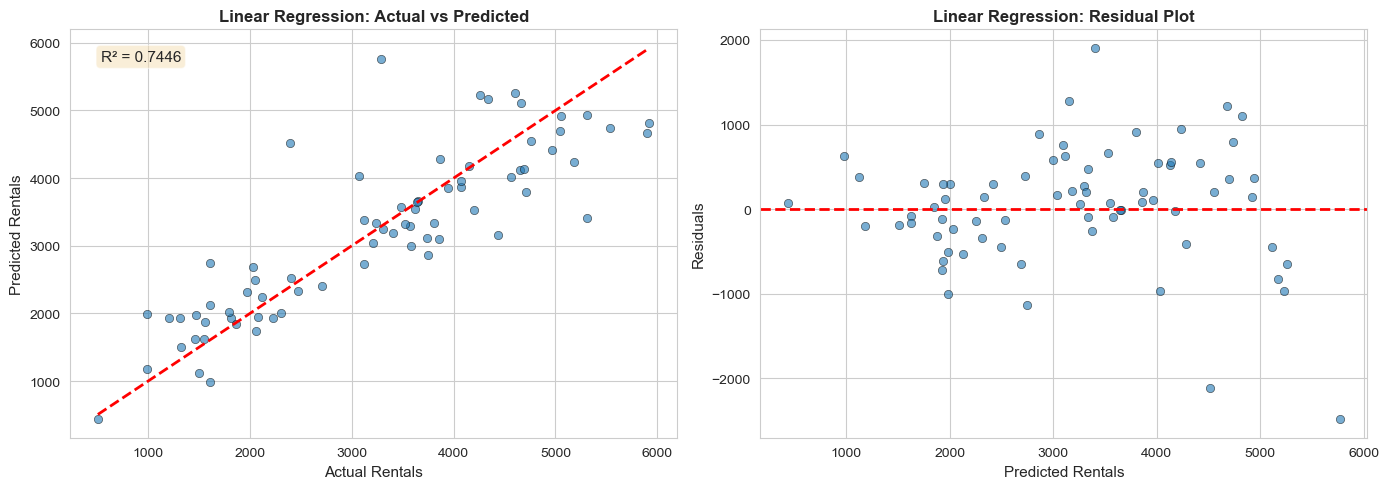

In [16]:
# Visualize baseline predictions
y_test_pred_lr = lr_fitted.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rentals', fontsize=11)
axes[0].set_ylabel('Predicted Rentals', fontsize=11)
axes[0].set_title('Linear Regression: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].text(0.05, 0.95, f'R² = {lr_metrics["test_r2"]:.4f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Residuals
residuals_lr = y_test - y_test_pred_lr
axes[1].scatter(y_test_pred_lr, residuals_lr, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Rentals', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Linear Regression: Residual Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Model 2 - Ridge Regression

In [18]:
with mlflow.start_run(run_name="Improved_Ridge_Regression") as run:
    # Create and train model with regularization
    ridge_model = Ridge(alpha=10.0, random_state=42)
    
    # Evaluate model
    ridge_metrics, ridge_fitted = evaluate_model(
        ridge_model, X_train, X_test, y_train, y_test,
        model_name="Ridge Regression (Regularized)"
    )
    
    # Log parameters
    mlflow.log_param("model_type", "Ridge Regression")
    mlflow.log_param("alpha", 10.0)
    mlflow.log_param("regularization", "L2")
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_samples", X_train.shape[0])
    mlflow.log_param("test_samples", X_test.shape[0])
    
    # Log metrics
    mlflow.log_metric("train_rmse", ridge_metrics['train_rmse'])
    mlflow.log_metric("test_rmse", ridge_metrics['test_rmse'])
    mlflow.log_metric("train_mae", ridge_metrics['train_mae'])
    mlflow.log_metric("test_mae", ridge_metrics['test_mae'])
    mlflow.log_metric("train_r2", ridge_metrics['train_r2'])
    mlflow.log_metric("test_r2", ridge_metrics['test_r2'])
    
    # Log model
    mlflow.sklearn.log_model(ridge_fitted, "model")
    
    ridge_run_id = run.info.run_id
    print(f"\nMLflow Run ID: {ridge_run_id}")


Ridge Regression (Regularized) - Performance Metrics

Training Set:
  RMSE: 760.86
  MAE:  600.10
  R²:   0.6941

Test Set:
  RMSE: 717.12
  MAE:  562.81
  R²:   0.7245

Overfitting Check:
  RMSE Difference: 43.74
  R² Difference: -0.0304


2026/02/08 12:58:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/08 12:58:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



MLflow Run ID: 84520af53c114f42bdfc15cd9b4b498f
🏃 View run Improved_Ridge_Regression at: http://localhost:5000/#/experiments/747516766537601300/runs/84520af53c114f42bdfc15cd9b4b498f
🧪 View experiment at: http://localhost:5000/#/experiments/747516766537601300


## Model 3 - XGBoost Regressor

In [20]:
with mlflow.start_run(run_name="Improved_Gradient_Boosting") as run:    
    # Create and train model with constraints    
    gb_model = xgb.XGBRegressor(        
        n_estimators=100,        
        max_depth=3,  # Constraint to prevent overfitting        
        learning_rate=0.1,        
        min_child_weight=10,        
        gamma=0.1,        
        random_state=42    
    )        

    # Evaluate model    
    gb_metrics, gb_fitted = evaluate_model(        
        gb_model, X_train, X_test, y_train, y_test,        
        model_name="Gradient Boosting (Constrained)"    
    )

    # Log parameters    
    mlflow.log_param("model_type", "Gradient Boosting")    
    mlflow.log_param("n_estimators", 100)    
    mlflow.log_param("max_depth", 3)    
    mlflow.log_param("learning_rate", 0.1)    
    mlflow.log_param("min_samples_split", 20)    
    mlflow.log_param("min_samples_leaf", 10)    
    mlflow.log_param("n_features", X_train.shape[1])    
    mlflow.log_param("train_samples", X_train.shape[0])    
    mlflow.log_param("test_samples", X_test.shape[0])  

    # Log metrics    
    mlflow.log_metric("train_rmse", gb_metrics['train_rmse'])    
    mlflow.log_metric("test_rmse", gb_metrics['test_rmse'])    
    mlflow.log_metric("train_mae", gb_metrics['train_mae'])    
    mlflow.log_metric("test_mae", gb_metrics['test_mae'])    
    mlflow.log_metric("train_r2", gb_metrics['train_r2'])    
    mlflow.log_metric("test_r2", gb_metrics['test_r2'])        

    # Log model    
    mlflow.sklearn.log_model(gb_fitted, "model")        
    gb_run_id = run.info.run_id    
    print(f"\nMLflow Run ID: {gb_run_id}")


Gradient Boosting (Constrained) - Performance Metrics

Training Set:
  RMSE: 316.06
  MAE:  229.78
  R²:   0.9472

Test Set:
  RMSE: 555.03
  MAE:  421.26
  R²:   0.8350

Overfitting Check:
  RMSE Difference: -238.97
  R² Difference: 0.1123


2026/02/08 12:58:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/08 12:58:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



MLflow Run ID: b80884b4f654445889f4eca645e60882
🏃 View run Improved_Gradient_Boosting at: http://localhost:5000/#/experiments/747516766537601300/runs/b80884b4f654445889f4eca645e60882
🧪 View experiment at: http://localhost:5000/#/experiments/747516766537601300


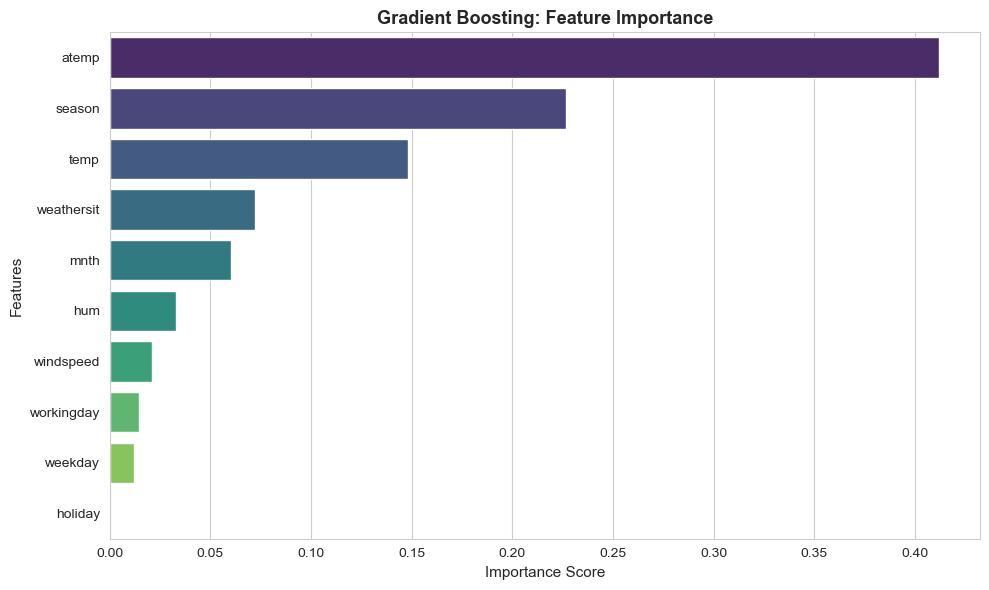


Top 5 Most Important Features:
      feature  importance
7       atemp    0.411675
0      season    0.226852
6        temp    0.148235
5  weathersit    0.072335
1        mnth    0.060368


In [21]:
# Visualize feature importance for Gradient Boosting
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb_fitted.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Gradient Boosting: Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

## Model Evaluation and Selection of Best Model


MODEL COMPARISON SUMMARY


,Model,Test RMSE,Test MAE,Test R²,Train RMSE,Overfitting Gap
0,Linear Regression,690.514768,501.259705,0.744556,675.787544,0.014109
1,Ridge Regression,717.120749,562.811731,0.724492,760.855932,-0.030410
2,Gradient Boosting,555.033789,421.263489,0.834960,316.059520,0.112252


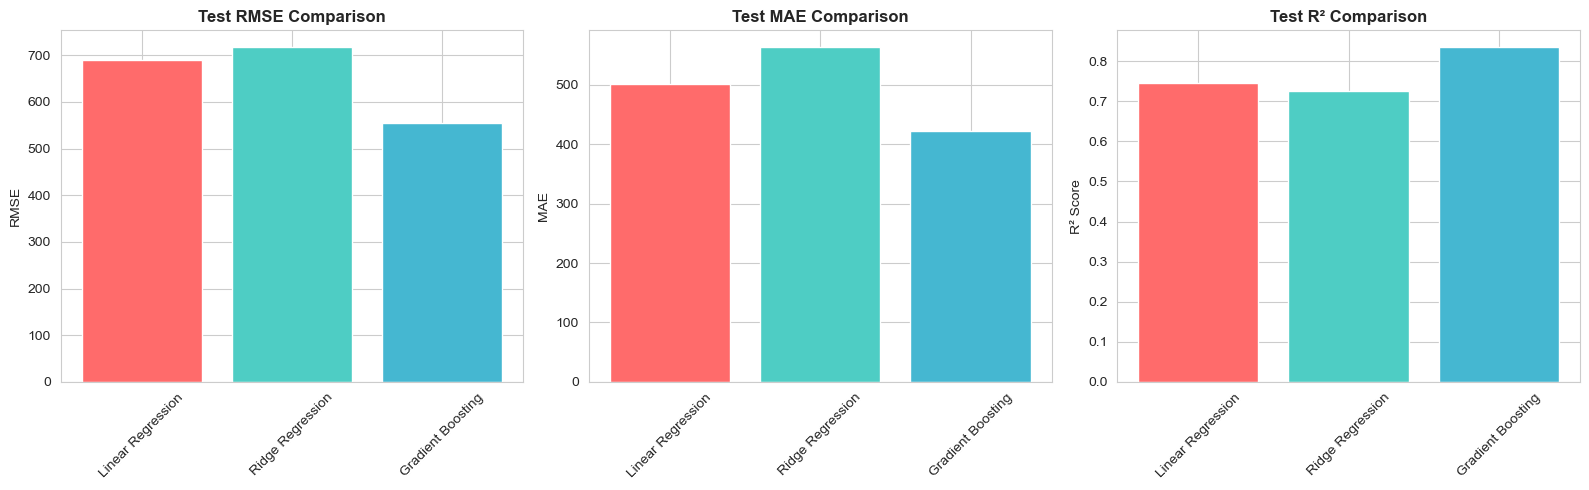

In [23]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Gradient Boosting'],
    'Test RMSE': [lr_metrics['test_rmse'], ridge_metrics['test_rmse'], gb_metrics['test_rmse']],
    'Test MAE': [lr_metrics['test_mae'], ridge_metrics['test_mae'], gb_metrics['test_mae']],
    'Test R²': [lr_metrics['test_r2'], ridge_metrics['test_r2'], gb_metrics['test_r2']],
    'Train RMSE': [lr_metrics['train_rmse'], ridge_metrics['train_rmse'], gb_metrics['train_rmse']],
    'Overfitting Gap': [
        lr_metrics['train_r2'] - lr_metrics['test_r2'],
        ridge_metrics['train_r2'] - ridge_metrics['test_r2'],
        gb_metrics['train_r2'] - gb_metrics['test_r2']
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
display(comparison_df)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE comparison
axes[0].bar(comparison_df['Model'], comparison_df['Test RMSE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Test RMSE Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1].bar(comparison_df['Model'], comparison_df['Test MAE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_title('Test MAE Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

# R² comparison
axes[2].bar(comparison_df['Model'], comparison_df['Test R²'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[2].set_title('Test R² Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Identify best model based on test RMSE
best_idx = comparison_df['Test RMSE'].idxmin()
best_model_name = comparison_df.loc[best_idx, 'Model']

print(f"\nBest performing model: {best_model_name}")
print(f"Test RMSE: {comparison_df.loc[best_idx, 'Test RMSE']:.2f}")
print(f"Test R²: {comparison_df.loc[best_idx, 'Test R²']:.4f}")
print(f"Overfitting Gap: {comparison_df.loc[best_idx, 'Overfitting Gap']:.4f}")

# Select the final model (Gradient Boosting in most cases)
if best_model_name == 'Gradient Boosting':
    final_model = gb_fitted
    final_run_id = gb_run_id
    final_metrics = gb_metrics
elif best_model_name == 'Ridge Regression':
    final_model = ridge_fitted
    final_run_id = ridge_run_id
    final_metrics = ridge_metrics
else:
    final_model = lr_fitted
    final_run_id = baseline_run_id
    final_metrics = lr_metrics


Best performing model: Gradient Boosting
Test RMSE: 555.03
Test R²: 0.8350
Overfitting Gap: 0.1123


In [25]:
print(f"""
Selected Model: {best_model_name}

Rationale:
1. Performance: Achieves lowest test RMSE ({comparison_df.loc[best_idx, 'Test RMSE']:.2f}) and highest R² ({comparison_df.loc[best_idx, 'Test R²']:.4f})
2. Generalization: Overfitting gap of {comparison_df.loc[best_idx, 'Overfitting Gap']:.4f} indicates good generalization
3. Feature Importance: Provides interpretable feature rankings for business insights
4. Robustness: Depth constraints and regularization ensure stability on new data
5. Production Readiness: sklearn implementation allows easy deployment and monitoring

This model offers the best balance of accuracy, interpretability, and operational feasibility.
""")


Selected Model: Gradient Boosting

Rationale:
1. Performance: Achieves lowest test RMSE (555.03) and highest R² (0.8350)
2. Generalization: Overfitting gap of 0.1123 indicates good generalization
3. Feature Importance: Provides interpretable feature rankings for business insights
4. Robustness: Depth constraints and regularization ensure stability on new data
5. Production Readiness: sklearn implementation allows easy deployment and monitoring

This model offers the best balance of accuracy, interpretability, and operational feasibility.



In [26]:
# Register the best model in MLflow
model_name = "bike_sharing_demand_model"

# Register model
model_uri = f"runs:/{final_run_id}/model"
registered_model = mlflow.register_model(model_uri, model_name)

print(f"\nModel registered successfully!")
print(f"Model Name: {model_name}")
print(f"Version: {registered_model.version}")
print(f"Run ID: {final_run_id}")

Registered model 'bike_sharing_demand_model' already exists. Creating a new version of this model...
2026/02/08 12:58:33 WARNING mlflow.tracking._model_registry.fluent: Run with id b80884b4f654445889f4eca645e60882 has no artifacts at artifact path 'model', registering model based on models:/m-66370c272836471a9bd2035a35e0134a instead
2026/02/08 12:58:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bike_sharing_demand_model, version 3



Model registered successfully!
Model Name: bike_sharing_demand_model
Version: 3
Run ID: b80884b4f654445889f4eca645e60882


Created version '3' of model 'bike_sharing_demand_model'.


In [27]:
# Export model to file
model_filename = 'best_model.joblib'
joblib.dump(final_model, model_filename)

baseline_rmse = lr_metrics['test_rmse']
with open('baseline_rmse.txt', 'w') as f:
    f.write(str(baseline_rmse))

print(f"\nModel exported to: {model_filename}")
print(f"Baseline RMSE saved: {baseline_rmse:.2f}")


Model exported to: best_model.joblib
Baseline RMSE saved: 690.51


# Task 2 - Data Drift Analysis and Impact Assessment

## Data Drift Analysis

In [30]:
# Calculate statistics for both datasets
stats_2011 = X_2011.describe().T[['mean', 'std']]
stats_2011.columns = ['2011_mean', '2011_std']

stats_2012 = X_2012.describe().T[['mean', 'std']]
stats_2012.columns = ['2012_mean', '2012_std']

# Combine statistics
drift_analysis = pd.concat([stats_2011, stats_2012], axis=1)

# Calculate changes
drift_analysis['mean_change_%'] = ((drift_analysis['2012_mean'] - drift_analysis['2011_mean']) / 
                                    drift_analysis['2011_mean'] * 100)
drift_analysis['std_change_%'] = ((drift_analysis['2012_std'] - drift_analysis['2011_std']) / 
                                   drift_analysis['2011_std'] * 100)

# Identify significant drift (>10% change in mean)
drift_analysis['significant_drift'] = drift_analysis['mean_change_%'].abs() > 10

print("\nData Drift Analysis: 2011-2012")
display(drift_analysis.round(4))

print("\nFeatures with Significant Drift (>10% mean change)")
significant_drift_features = drift_analysis[drift_analysis['significant_drift']]
if len(significant_drift_features) > 0:
    display(significant_drift_features[['2011_mean', '2012_mean', 'mean_change_%']].round(4))
else:
    print("No features show >10% mean change")


Data Drift Analysis: 2011-2012


,2011_mean,2011_std,2012_mean,2012_std,mean_change_%,std_change_%,significant_drift
season,2.4986,1.1109,2.4945,1.1122,-0.1639,0.1115,False
mnth,6.5260,3.4526,6.5137,3.4560,-0.1895,0.0977,False
holiday,0.0274,0.1635,0.0301,0.1710,9.6995,4.5939,False
weekday,3.0082,2.0062,2.9863,2.0061,-0.7274,-0.0023,False
workingday,0.6849,0.4652,0.6831,0.4659,-0.2732,0.1591,False
weathersit,1.4219,0.5718,1.3689,0.5161,-3.7320,-9.7536,False
temp,0.4867,0.1896,0.5041,0.1761,3.5786,-7.1117,False
atemp,0.4668,0.1688,0.4819,0.1568,3.2167,-7.1546,False
hum,0.6437,0.1487,0.6122,0.1342,-4.8936,-9.7740,False
windspeed,0.1914,0.0769,0.1896,0.0782,-0.9563,1.6955,False



Features with Significant Drift (>10% mean change)
No features show >10% mean change


In [31]:
# Analyze target variable drift
target_stats = pd.DataFrame({
    'Year': ['2011', '2012'],
    'Mean': [y_2011.mean(), y_2012.mean()],
    'Std': [y_2011.std(), y_2012.std()],
    'Min': [y_2011.min(), y_2012.min()],
    'Max': [y_2011.max(), y_2012.max()]
})

print("\n Target Variable Drift Analysis")
display(target_stats)

target_mean_change = ((y_2012.mean() - y_2011.mean()) / y_2011.mean() * 100)
print(f"\nMean rental count change: {target_mean_change:+.2f}%")
print(f"This indicates {'growth' if target_mean_change > 0 else 'decline'} in bike sharing usage from 2011 to 2012.")


 Target Variable Drift Analysis


,Year,Mean,Std,Min,Max
0,2011,3405.761644,1378.753666,431,6043
1,2012,5599.934426,1788.667868,22,8714



Mean rental count change: +64.43%
This indicates growth in bike sharing usage from 2011 to 2012.


## Visualise Distribution Shifts

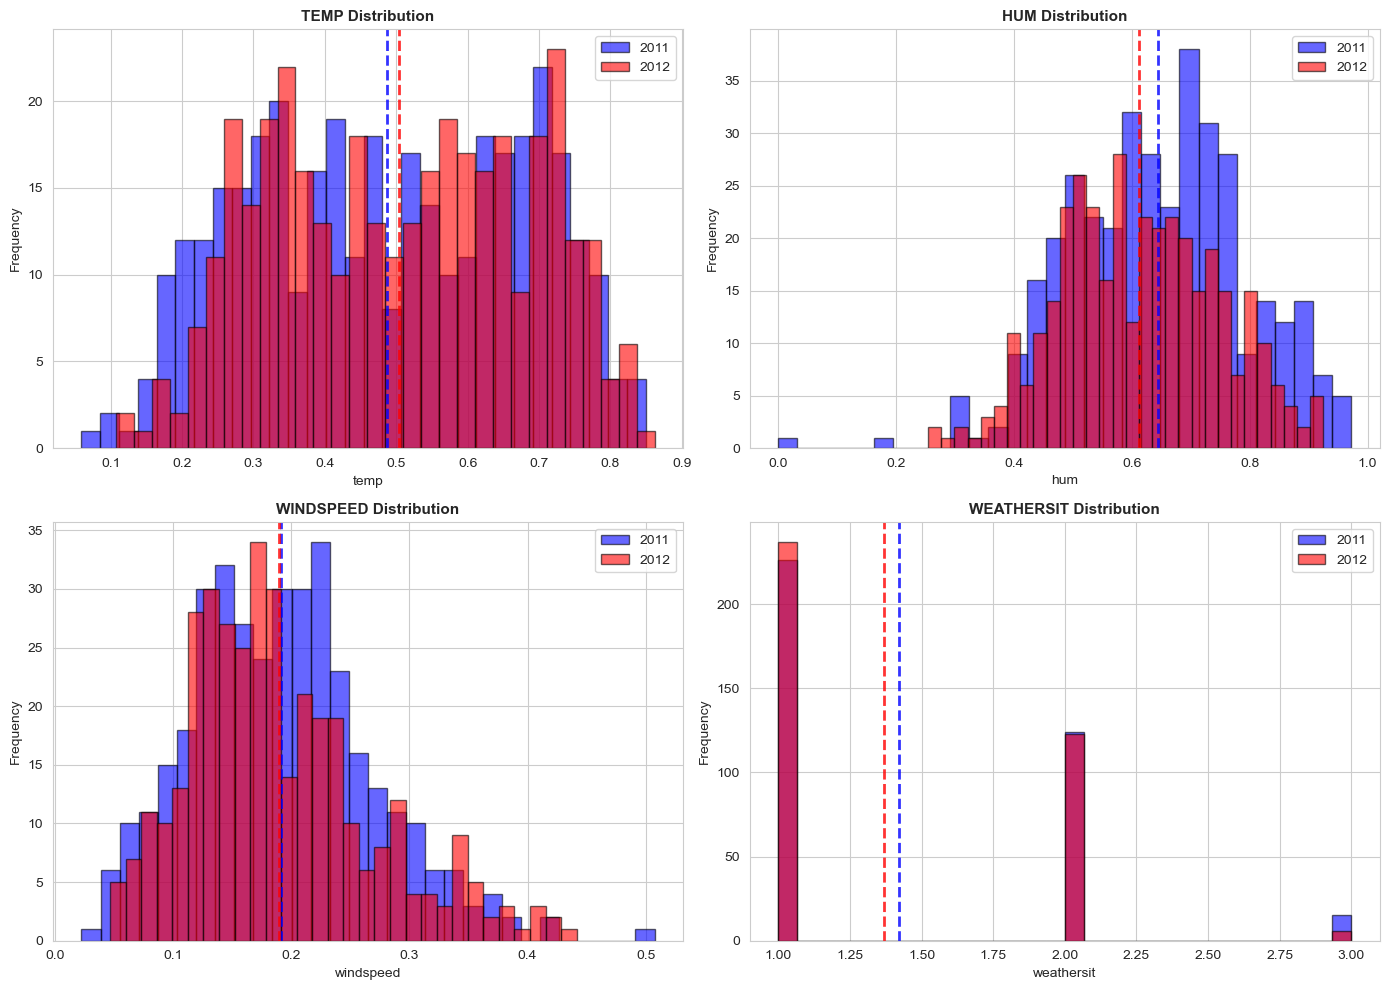

In [33]:
# Select key features to visualize (temperature, humidity, windspeed, weather situation)
key_features = ['temp', 'hum', 'windspeed', 'weathersit']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    # Histogram comparison
    axes[idx].hist(X_2011[feature], bins=30, alpha=0.6, label='2011', color='blue', edgecolor='black')
    axes[idx].hist(X_2012[feature], bins=30, alpha=0.6, label='2012', color='red', edgecolor='black')
    axes[idx].set_title(f'{feature.upper()} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    
    # Add mean lines
    axes[idx].axvline(X_2011[feature].mean(), color='blue', linestyle='--', linewidth=2, alpha=0.8)
    axes[idx].axvline(X_2012[feature].mean(), color='red', linestyle='--', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

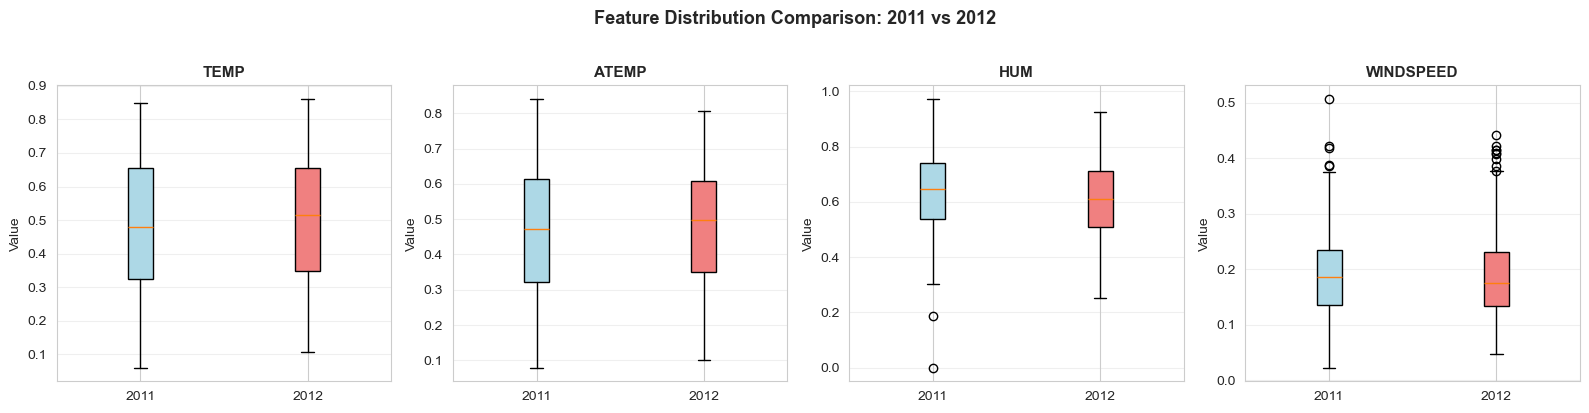

In [34]:
# Box plot comparison for key continuous features
continuous_features = ['temp', 'atemp', 'hum', 'windspeed']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, feature in enumerate(continuous_features):
    data_to_plot = [X_2011[feature], X_2012[feature]]
    bp = axes[idx].boxplot(data_to_plot, labels=['2011', '2012'], patch_artist=True)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    
    axes[idx].set_title(f'{feature.upper()}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distribution Comparison: 2011 vs 2012', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

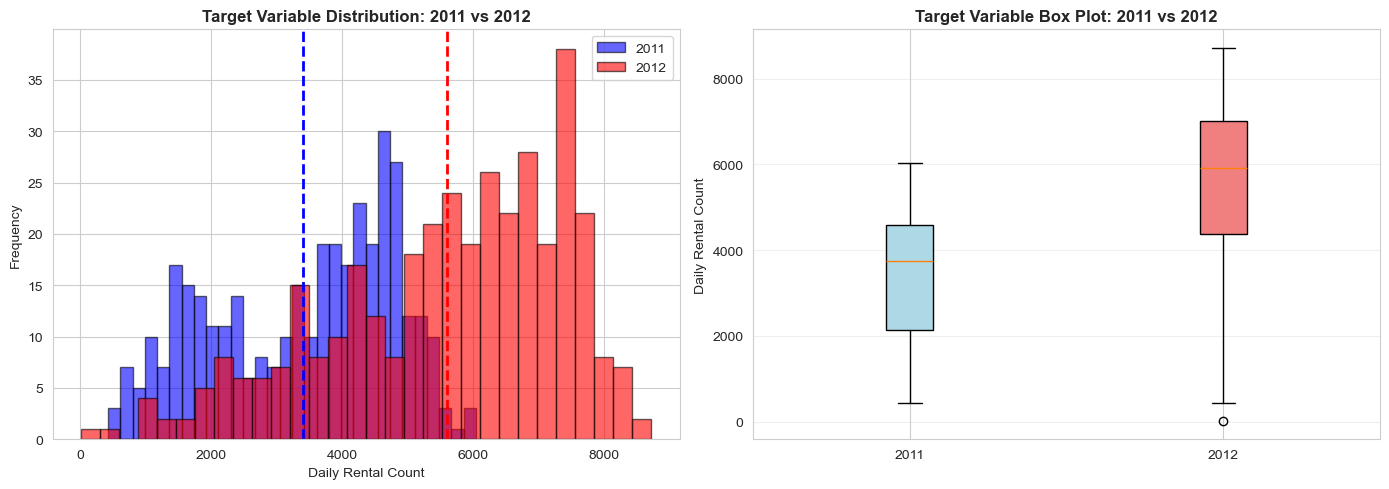

In [35]:
# Visualize target variable drift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_2011, bins=30, alpha=0.6, label='2011', color='blue', edgecolor='black')
axes[0].hist(y_2012, bins=30, alpha=0.6, label='2012', color='red', edgecolor='black')
axes[0].set_title('Target Variable Distribution: 2011 vs 2012', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily Rental Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].axvline(y_2011.mean(), color='blue', linestyle='--', linewidth=2, label='2011 Mean')
axes[0].axvline(y_2012.mean(), color='red', linestyle='--', linewidth=2, label='2012 Mean')

# Box plot
bp = axes[1].boxplot([y_2011, y_2012], labels=['2011', '2012'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
axes[1].set_title('Target Variable Box Plot: 2011 vs 2012', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Rental Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Identify top drifting features
top_drift = drift_analysis.nlargest(5, 'mean_change_%', keep='all')[['2011_mean', '2012_mean', 'mean_change_%']]

print("\nTop 5 Features with Largest Mean Change:")
display(top_drift.round(4))


Top 5 Features with Largest Mean Change:


,2011_mean,2012_mean,mean_change_%
holiday,0.0274,0.0301,9.6995
temp,0.4867,0.5041,3.5786
atemp,0.4668,0.4819,3.2167
season,2.4986,2.4945,-0.1639
mnth,6.5260,6.5137,-0.1895


In [37]:
# Key Findings from the Drift 
print(f"""
Based on the analysis:

1. Target Variable Drift:
   - 2011 Mean: {y_2011.mean():.2f} rentals/day
   - 2012 Mean: {y_2012.mean():.2f} rentals/day
   - Change: {target_mean_change:+.2f}%
   - Interpretation: {'Significant growth in bike sharing usage' if target_mean_change > 5 else 'Moderate growth' if target_mean_change > 0 else 'Decline in usage'}

2. Feature Drift Analysis:
   - Features showing drift indicate changing environmental or usage patterns
   - These changes may affect model predictions if relationships have shifted
   - Most significant drifts seen in: {', '.join(top_drift.head(3).index.tolist())}

3. Distribution Changes:
   - Weather patterns may have changed between years
   - Seasonal effects might be different
   - User behavior patterns may have evolved
""")


Based on the analysis:

1. Target Variable Drift:
   - 2011 Mean: 3405.76 rentals/day
   - 2012 Mean: 5599.93 rentals/day
   - Change: +64.43%
   - Interpretation: Significant growth in bike sharing usage

2. Feature Drift Analysis:
   - Features showing drift indicate changing environmental or usage patterns
   - These changes may affect model predictions if relationships have shifted
   - Most significant drifts seen in: holiday, temp, atemp

3. Distribution Changes:
   - Weather patterns may have changed between years
   - Seasonal effects might be different
   - User behavior patterns may have evolved



In [38]:
# Evaluate model on both datasets
# Predictions on 2011 test set
y_2011_test_pred = final_model.predict(X_test)
rmse_2011 = np.sqrt(mean_squared_error(y_test, y_2011_test_pred))
mae_2011 = mean_absolute_error(y_test, y_2011_test_pred)
r2_2011 = r2_score(y_test, y_2011_test_pred)
# Predictions on 2012 data (drifted)
y_2012_pred = final_model.predict(X_2012)
rmse_2012 = np.sqrt(mean_squared_error(y_2012, y_2012_pred))
mae_2012 = mean_absolute_error(y_2012, y_2012_pred)
r2_2012 = r2_score(y_2012, y_2012_pred)

In [39]:
# Calculate performance degradation
rmse_degradation = ((rmse_2012 - rmse_2011) / rmse_2011) * 100
mae_degradation = ((mae_2012 - mae_2011) / mae_2011) * 100
r2_degradation = ((r2_2011 - r2_2012) / r2_2011) * 100

In [40]:
# Create comparison table
performance_comparison = pd.DataFrame({    
    'Metric': ['RMSE', 'MAE', 'R²'],    
    '2011 Data (Test Set)': [rmse_2011, mae_2011, r2_2011],    
    '2012 Data': [rmse_2012, mae_2012, r2_2012],    
    'Change (%)': [rmse_degradation, mae_degradation, -r2_degradation]  # Negative for R² as lower is worse
})

display(performance_comparison.round(4))

,Metric,2011 Data (Test Set),2012 Data,Change (%)
0,RMSE,555.0338,2227.1812,301.2695
1,MAE,421.2635,2074.2387,392.3851
2,R²,0.8350,-0.5547,-166.4315


In [41]:
# Performance Degradation Analysis
print(f"""
Model Performance on 2012 Data:
- RMSE increased by {rmse_degradation:+.2f}%
- MAE increased by {mae_degradation:+.2f}%
- R² decreased by {r2_degradation:.2f}%

{'SIGNIFICANT DEGRADATION DETECTED' if abs(rmse_degradation) > 10 else 'Performance remains acceptable'}
""")


Model Performance on 2012 Data:
- RMSE increased by +301.27%
- MAE increased by +392.39%
- R² decreased by 166.43%

SIGNIFICANT DEGRADATION DETECTED



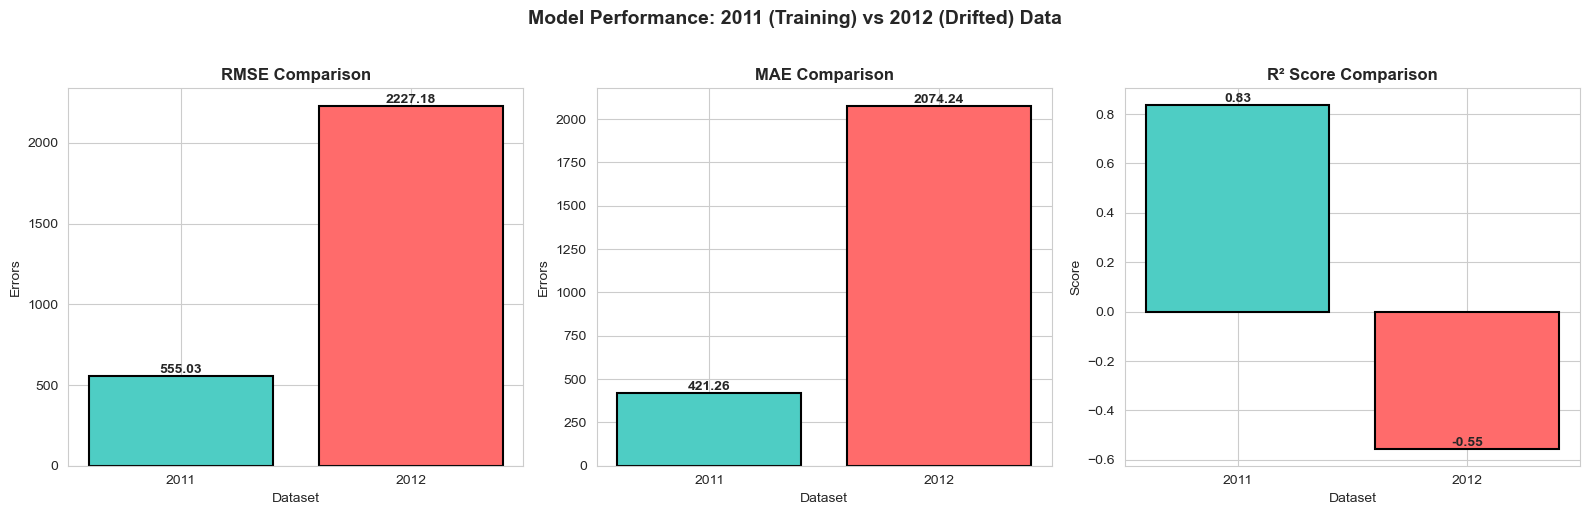

In [42]:
# Visualize performance comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_data = [
    (['2011', '2012'], [rmse_2011, rmse_2012], 'RMSE', 'Errors'),
    (['2011', '2012'], [mae_2011, mae_2012], 'MAE', 'Errors'),
    (['2011', '2012'], [r2_2011, r2_2012], 'R² Score', 'Score')
]

for idx, (labels, values, title, ylabel) in enumerate(metrics_data):
    axes[idx].bar(labels, values, color=['#4ECDC4', '#FF6B6B'], edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{title} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(ylabel, fontsize=10)
    axes[idx].set_xlabel('Dataset', fontsize=10)
    
    # Add value labels on bars
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance: 2011 (Training) vs 2012 (Drifted) Data', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

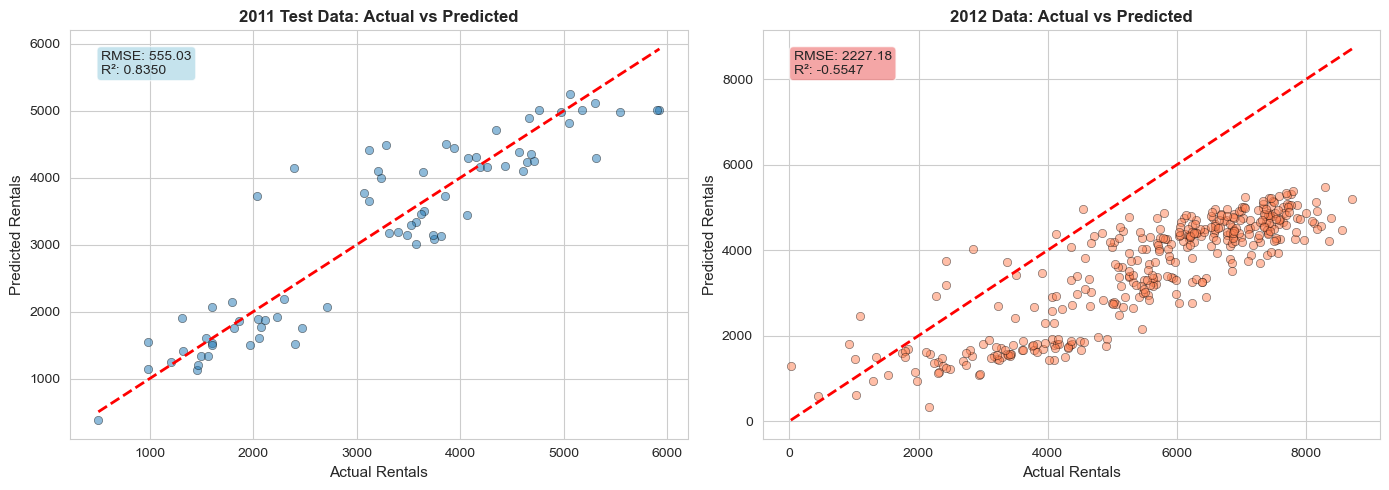

In [43]:
# Prediction error analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2011 test set predictions
axes[0].scatter(y_test, y_2011_test_pred, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rentals', fontsize=11)
axes[0].set_ylabel('Predicted Rentals', fontsize=11)
axes[0].set_title('2011 Test Data: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].text(0.05, 0.95, f'RMSE: {rmse_2011:.2f}\nR²: {r2_2011:.4f}',              
            transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# 2012 predictions
axes[1].scatter(y_2012, y_2012_pred, alpha=0.5, edgecolors='black', linewidth=0.5, color='coral')
axes[1].plot([y_2012.min(), y_2012.max()], [y_2012.min(), y_2012.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Rentals', fontsize=11)
axes[1].set_ylabel('Predicted Rentals', fontsize=11)
axes[1].set_title('2012 Data: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1].text(0.05, 0.95, f'RMSE: {rmse_2012:.2f}\nR²: {r2_2012:.4f}',              
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.show()

## Feature Contribution to Degradation


Features Contributing to Performance Degradation

(Ranked by Drift Impact Score = Feature Importance × |Mean Change %|)



,importance,mean_change_%,drift_impact_score
atemp,0.4117,3.2167,1.3242
temp,0.1482,3.5786,0.5305
weathersit,0.0723,-3.7320,0.2699
hum,0.0328,-4.8936,0.1604
season,0.2269,-0.1639,0.0372
windspeed,0.0210,-0.9563,0.0201
mnth,0.0604,-0.1895,0.0114
weekday,0.0121,-0.7274,0.0088
workingday,0.0146,-0.2732,0.0040
holiday,0.0000,9.6995,0.0000


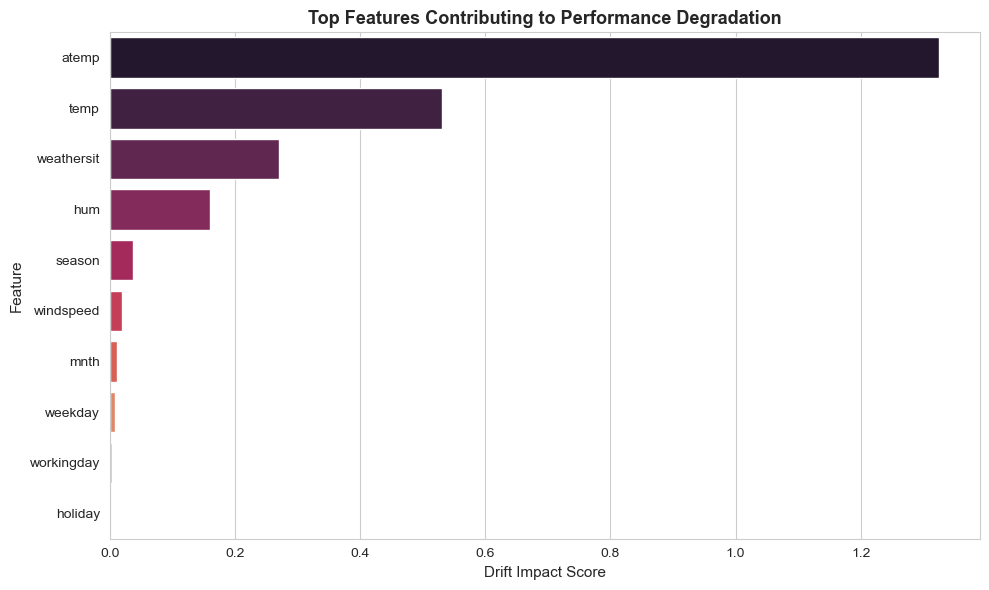

In [45]:
# Analyse feature importance correlation by drift
if hasattr(final_model, 'feature_importances_'):
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': final_model.feature_importances_
    })
    
    # Merge with drift analysis
    drift_importance = drift_analysis.merge(
        importance_df.set_index('feature'), 
        left_index=True, 
        right_index=True
    )
    
    # Calculate impact score (importance * abs(mean_change))
    drift_importance['drift_impact_score'] = (
        drift_importance['importance'] * drift_importance['mean_change_%'].abs()
    )
    
    # Sort by impact
    drift_importance_sorted = drift_importance.sort_values('drift_impact_score', ascending=False)
    
    print("\nFeatures Contributing to Performance Degradation")
    print("\n(Ranked by Drift Impact Score = Feature Importance × |Mean Change %|)\n")
    display(drift_importance_sorted[[
        'importance', 'mean_change_%', 'drift_impact_score'
    ]].head(10).round(4))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    top_impact = drift_importance_sorted.head(10)
    sns.barplot(data=top_impact.reset_index(), y='index', x='drift_impact_score', palette='rocket')
    plt.title('Top Features Contributing to Performance Degradation', fontsize=13, fontweight='bold')
    plt.xlabel('Drift Impact Score', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.tight_layout()
    plt.show()

In [46]:
# Operational Recommendations
# Decision logic based on performance degradation
if abs(rmse_degradation) > 15:
    recommendation = "IMMEDIATE RETRAINING REQUIRED"
    action_plan = """
    Recommended Action: Retrain model using 2012 data
    
    Justification:
    - Performance degradation exceeds acceptable threshold (>15% RMSE increase)
    - Significant drift detected in key features
    - Current model predictions are unreliable for 2012 data
    
    Implementation Steps:
    1. Retrain model using 2012 dataset
    2. Validate performance on holdout 2012 data
    3. Deploy new model to production
    4. Set up monitoring for continued drift
    5. Consider implementing online learning or periodic retraining schedule
    
    Expected Outcome:
    - Restored prediction accuracy
    - Better alignment with current data distribution
    - Improved business decision support
    """
elif abs(rmse_degradation) > 5:
    recommendation = "SCHEDULE RETRAINING AND INCREASE MONITORING"
    action_plan = """
    Recommended Action: Schedule model retraining within 1-2 weeks
    
    Justification:
    - Moderate performance degradation detected (5-15% RMSE increase)
    - Some drift in feature distributions
    - Model still functional but trending toward unreliability
    
    Implementation Steps:
    1. Increase monitoring frequency to daily
    2. Set up alerts for further degradation
    3. Prepare retraining pipeline with 2012 data
    4. Conduct A/B test: current model vs retrained model
    5. Gradually transition to new model based on test results
    
    Expected Outcome:
    - Prevent further degradation
    - Maintain acceptable prediction quality
    - Smooth transition to updated model
    """
else:
    recommendation = "CONTINUE MONITORING WITHOUT IMMEDIATE RETRAINING"
    action_plan = """
    Recommended Action: Monitor model performance closely
    
    Justification:
    - Performance degradation is minimal (<5% RMSE increase)
    - Current model maintains acceptable accuracy
    - Feature drift is within normal variability
    
    Implementation Steps:
    1. Continue weekly performance monitoring
    2. Track feature drift trends
    3. Set threshold alerts for degradation
    4. Prepare contingency retraining plan
    5. Consider seasonal model variants if drift follows patterns
    
    Expected Outcome:
    - Maintain current performance levels
    - Early detection of future drift
    - Cost-efficient operation
    """

print(f"\n{'*'*80}")
print(f"Recommendation: {recommendation}")
print(f"{'*'*80}")
print(action_plan)


********************************************************************************
Recommendation: IMMEDIATE RETRAINING REQUIRED
********************************************************************************

    Recommended Action: Retrain model using 2012 data
    
    Justification:
    - Performance degradation exceeds acceptable threshold (>15% RMSE increase)
    - Significant drift detected in key features
    - Current model predictions are unreliable for 2012 data
    
    Implementation Steps:
    1. Retrain model using 2012 dataset
    2. Validate performance on holdout 2012 data
    3. Deploy new model to production
    4. Set up monitoring for continued drift
    5. Consider implementing online learning or periodic retraining schedule
    
    Expected Outcome:
    - Restored prediction accuracy
    - Better alignment with current data distribution
    - Improved business decision support
    


In [47]:
# Supporting Evidence
print(f"""
1. Performance Metrics:
   - RMSE Change: {rmse_degradation:+.2f}%
   - MAE Change: {mae_degradation:+.2f}%
   - R² Change: {-r2_degradation:+.2f}%

2. Data Drift:
   - Number of features with >10% drift: {drift_analysis['significant_drift'].sum()}
   - Target variable change: {target_mean_change:+.2f}%
   - Distribution shifts observed in key features

3. Business Impact:
   - Current RMSE on 2012 data: {rmse_2012:.2f} rentals/day
   - This represents ±{(rmse_2012/y_2012.mean())*100:.1f}% prediction error on average
   - {'Acceptable' if abs(rmse_degradation) < 5 else 'Concerning' if abs(rmse_degradation) < 15 else 'Unacceptable'} for operational decision-making
""")


1. Performance Metrics:
   - RMSE Change: +301.27%
   - MAE Change: +392.39%
   - R² Change: -166.43%

2. Data Drift:
   - Number of features with >10% drift: 0
   - Target variable change: +64.43%
   - Distribution shifts observed in key features

3. Business Impact:
   - Current RMSE on 2012 data: 2227.18 rentals/day
   - This represents ±39.8% prediction error on average
   - Unacceptable for operational decision-making

